In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/MyDrive/Data set/supply_chain_data.csv"
MPSCData=pd.read_csv(path)
MPSCData.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,75,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,68,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,10,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,40,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,20,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [ ]:
#Checking the number of variables and their type
MPSCData.dtypes

,0
Product type,object
SKU,object
Price,float64
Availability,int64
Number of products sold,int64
Revenue generated,float64
Customer demographics,object
Stock levels,int64
Lead times,int64
Order quantities,int64


In [ ]:
MPSCData.value_counts(['Product type'])

,count
Product type,
skincare,41
haircare,36
cosmetics,29


In [ ]:
MPSCData.value_counts(['Customer demographics'])

,count
Customer demographics,
Unknown,33
Female,28
Non-binary,23
Male,22


In [ ]:
MPSCData.value_counts(['Shipping carriers'])

,count
Shipping carriers,
Carrier B,46
Carrier A,31
Carrier C,29


In [ ]:
MPSCData.value_counts(['Supplier name'])

,count
Supplier name,
Supplier 1,29
Supplier 2,24
Supplier 4,19
Supplier 5,18
Supplier 3,16


In [ ]:
MPSCData.value_counts(['Location'])

,count
Location,
Kolkata,26
Mumbai,25
Bangalore,20
Chennai,20
Delhi,15


In [ ]:
MPSCData.value_counts(['Inspection results'])

,count
Inspection results,
Pending,46
Fail,36
Pass,24


In [ ]:
MPSCData.value_counts(['Transportation modes'])

,count
Transportation modes,
Road,32
Rail,29
Air,27
Sea,18


In [ ]:
MPSCData.value_counts(['Routes'])

,count
Routes,
Route A,46
Route B,39
Route C,21


In [ ]:
#Checking the lengths of the array dimensions
MPSCData.shape

(106, 24)

In [ ]:
#Checking the type of column structure
MPSCData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             106 non-null    object 
 1   SKU                      106 non-null    object 
 2   Price                    106 non-null    float64
 3   Availability             106 non-null    int64  
 4   Number of products sold  106 non-null    int64  
 5   Revenue generated        106 non-null    float64
 6   Customer demographics    106 non-null    object 
 7   Stock levels             106 non-null    int64  
 8   Lead times               106 non-null    int64  
 9   Order quantities         106 non-null    int64  
 10  Shipping times           106 non-null    int64  
 11  Shipping carriers        106 non-null    object 
 12  Shipping costs           106 non-null    float64
 13  Supplier name            106 non-null    object 
 14  Location                 1

In [ ]:
# Returning statistical description of the data in the Dataset
MPSCData.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,49.682266,48.792453,462.707547,5877.516344,53.830189,15.783019,48.537736,5.764151,5.683366,17.141509,567.047170,14.915094,46.944038,2.267169,522.795889
std,31.325253,30.934868,303.219391,2698.343762,25.698424,8.879087,26.675537,2.706436,2.685534,8.774898,261.733794,8.875990,28.530375,1.454004,257.829361
min,1.699976,1.000000,8.000000,1061.618523,5.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.000000,1.085069,0.018608,103.916248
25%,19.284259,22.250000,178.750000,2886.724877,30.000000,8.000000,26.000000,4.000000,3.720829,10.000000,359.000000,7.000000,23.308130,1.052861,314.642334
50%,51.239830,46.000000,410.000000,6108.634366,60.000000,16.500000,51.500000,6.000000,5.667884,18.000000,566.000000,14.000000,45.905622,2.099035,513.928987
75%,77.668694,75.000000,704.750000,8219.335393,75.000000,24.000000,70.500000,8.000000,8.017071,24.750000,793.750000,23.000000,68.083595,3.517800,762.137864
max,99.171329,100.000000,996.000000,9866.465458,98.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.000000,99.466109,4.939255,997.413450


# **Data Cleaning**

In [ ]:
#Checking the number of missing values for each variable
np.sum(MPSCData.isna())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


In [ ]:
#Checking number of Duplicated values
MPSCData.duplicated().sum()

np.int64(0)

# **Cleaning**

In [ ]:
MPSCData.columns = [col.lower().replace(' ', '_') for col in MPSCData.columns]
MPSCData.rename(columns=lambda x: x.replace("(", "").replace(")", ""), inplace=True)
MPSCData.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'lead_times', 'order_quantities', 'shipping_times',
       'shipping_carriers', 'shipping_costs', 'supplier_name', 'location',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'costs'],
      dtype='object')

In [ ]:
fig = px.scatter(MPSCData, x='price',
                 y='revenue_generated',
                 color='product_type',
                 hover_data=['number_of_products_sold'],
                 trendline="ols")
fig.show()

In [ ]:
sales_data = MPSCData.groupby('product_type')['number_of_products_sold'].sum().reset_index()

pie_chart = px.pie(sales_data, values='number_of_products_sold', names='product_type',
                   title='sales_by_product_type',
                   hover_data=['number_of_products_sold'],
                   hole=0.5,
                   color_discrete_sequence=px.colors.qualitative.Pastel)

pie_chart.update_traces(textposition='inside', textinfo='percent+label')
pie_chart.show()

**So 45% of the business comes from skincare products, 29.5% from haircare, and 25.5% from cosmetics.**

**Total Revenue by Shipping Carrier**

In [ ]:
import plotly.graph_objects as go
total_revenue = MPSCData.groupby('shipping_carriers')['revenue_generated'].sum().reset_index()
fig = go.Figure()
fig.add_trace(go.Bar(x=total_revenue['shipping_carriers'],
                     y=total_revenue['revenue_generated']))
fig.update_layout(title='total_revenue_by_shipping-carrier',
                  xaxis_title='shipping_carrier',
                  yaxis_title='revenue_generated')
fig.show()

**Product type**

In [ ]:
avg_lead_time = MPSCData.groupby('product_type')['lead_time'].mean().reset_index()
avg_manufacturing_costs = MPSCData.groupby('product_type')['manufacturing_costs'].mean().reset_index()
result = pd.merge(avg_lead_time, avg_manufacturing_costs, on='product_type')
result.rename(columns={'lead_time': 'average_lead)time', 'manufacturing_costs': 'average_manufacturing_costs'}, inplace=True)
print(result)

  product_type  average_lead)time  average_manufacturing_costs
0    cosmetics          13.724138                    43.614542
1     haircare          18.777778                    47.719535
2     skincare          18.121951                    48.618124


**Analyzing SKUs**

In [ ]:
revenue_chart = px.line(MPSCData, x='sku',
                        y='revenue_generated',
                        title='Revenue Generated by SKU')
revenue_chart.show()

**Stock Levels by SKU**

In [ ]:
stock_chart = px.line(MPSCData, x='sku',
                      y='stock_levels',
                      title='Stock Levels by SKU')
stock_chart.show()

In [ ]:
order_quantity_chart = px.bar(MPSCData, x='sku',
                              y='order_quantities',
                              title='Order Quantity by SKU')
order_quantity_chart.show()


**Shipping Costs by Carrier**

In [ ]:
shipping_cost_chart = px.bar(MPSCData, x='shipping_carriers',
                             y='shipping_costs',
                             title='Shipping Costs by Carrier')
shipping_cost_chart.show()

**Conclusion: Carrier B helps the company in more revenue. It is also the most costly Carrier among the three.**

**Cost Distribution by Transportation Mode**

In [ ]:
transportation_chart = px.pie(MPSCData,
                              values='costs',
                              names='transportation_modes',
                              title='cost_distribution_by_transportation_mode',
                              hole=0.5,
                              color_discrete_sequence=px.colors.qualitative.Pastel)
transportation_chart.show()

**Conclusion: company spends more on Road and Rail modes of transportation for the transportation of Goods.**

**Average Defect Rates by Product Type**

In [ ]:
defect_rates_by_product = MPSCData.groupby('product_type')['defect_rates'].mean().reset_index()

fig = px.bar(defect_rates_by_product, x='product_type', y='defect_rates',
             title='Average Defect Rates by Product Type')
fig.show()

**Conclusion: the defect rate of haircare products is higher.**

**Defect Rates by Transportation Mode**

In [ ]:
pivot_table = pd.pivot_table(MPSCData, values='defect_rates',
                             index=['transportation_modes'],
                             aggfunc='mean')

transportation_chart = px.pie(values=pivot_table["defect_rates"],
                              names=pivot_table.index,
                              title='Defect Rates by Transportation Mode',
                              hole=0.5,
                              color_discrete_sequence=px.colors.qualitative.Pastel)
transportation_chart.show()

**Conclusion: Road transportation results in a higher defect rate, and Air transportation has the lowest defect rate.**

# **Correlation Matrix**

In [ ]:
from sklearn import preprocessing
MP_SC = MPSCData.copy()
le = preprocessing.LabelEncoder()

#convert the categorical columns into numeric

MP_SC['product_type']= le.fit_transform(MP_SC['product_type'])
MP_SC['customer_demographics']= le.fit_transform(MP_SC['customer_demographics'])
MP_SC['shipping_carriers']= le.fit_transform(MP_SC['shipping_carriers'])
MP_SC['sku']= le.fit_transform(MP_SC['sku'])
MP_SC['inspection_results']= le.fit_transform(MP_SC['inspection_results'])
MP_SC['transportation_modes']= le.fit_transform(MP_SC['transportation_modes'])
MP_SC['routes']= le.fit_transform(MP_SC['routes'])
MP_SC['supplier_name']= le.fit_transform(MP_SC['supplier_name'])
MP_SC['location']= le.fit_transform(MP_SC['location'])

<Axes: >

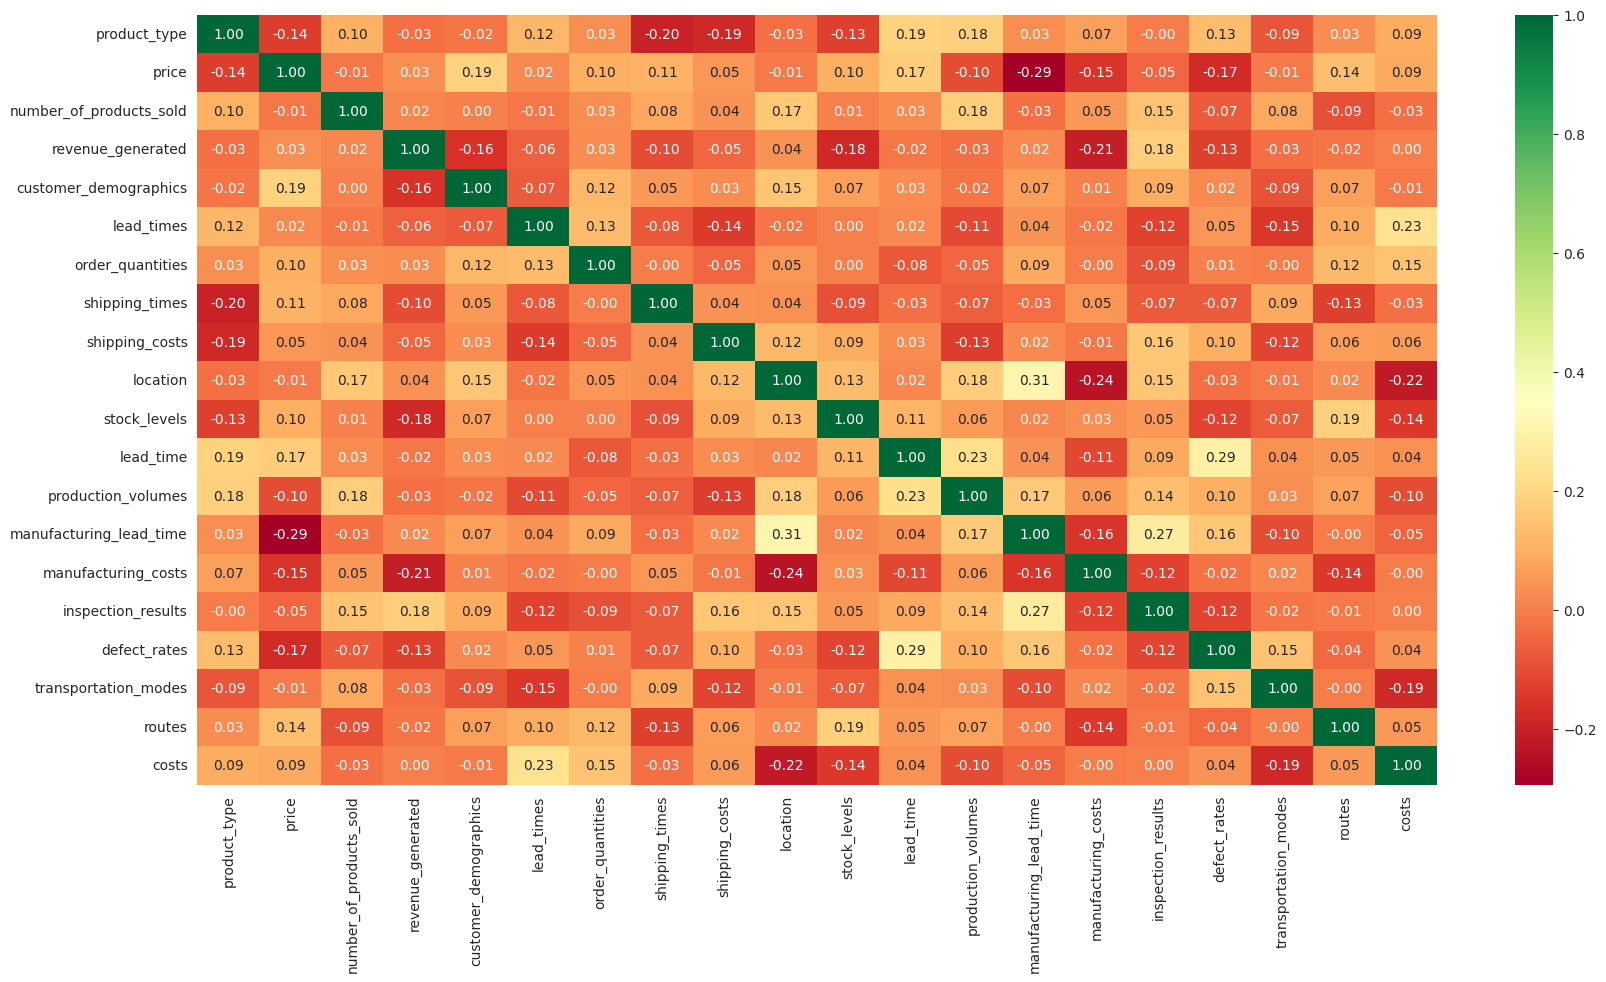

In [ ]:
SC_features=MP_SC[['product_type','price',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'lead_times', 'order_quantities', 'shipping_times',
        'shipping_costs', 'location', 'stock_levels',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'costs']]
fig = plt.figure(figsize=(20,10))
sns.heatmap(SC_features.corr(), annot = True, fmt = '.2f', cmap = "RdYlGn")

**Conclusion: Manufacturing lead time & price is highest negative correlation menas as manufacturing lead time increases price decreases**


Manufacturing lead time & location is highest positive correlation lets find the manufacuring lead time of each location

In [ ]:
MP_SC['location'] = le.inverse_transform(MP_SC['location'])

MP_SC.groupby('location')['manufacturing_lead_time'].mean()

,manufacturing_lead_time
location,
Bangalore,11.900000
Chennai,12.650000
Delhi,13.533333
Kolkata,14.846154
Mumbai,20.040000


**Mumbai has highest manufacturing lead time & Banglore has lowest manufacturing lead time**

In [ ]:
# calculate the correlation of each city with manufacturing_lead_time.
location_dummies = pd.get_dummies(MP_SC['location'], prefix='Location')

# Combine with original dataframe
MP_SC_onehot = pd.concat([MP_SC, location_dummies], axis=1)
corr = MP_SC_onehot.corr(numeric_only=True)
corr['manufacturing_lead_time'].filter(like='Location').sort_values(ascending=False)   #sorting

,manufacturing_lead_time
Location_Mumbai,0.322296
Location_Kolkata,-0.004449
Location_Delhi,-0.063504
Location_Chennai,-0.123650
Location_Bangalore,-0.164592


**Conclusion: Mumbai has positive correaltion with manufacturing lead time & Banglore has negative correlation with manufacturing lead time**

In [ ]:
from pylab import rcParams
%matplotlib inline
import seaborn as sb
rcParams['figure.figsize']=3,2
sb.set_style('whitegrid')

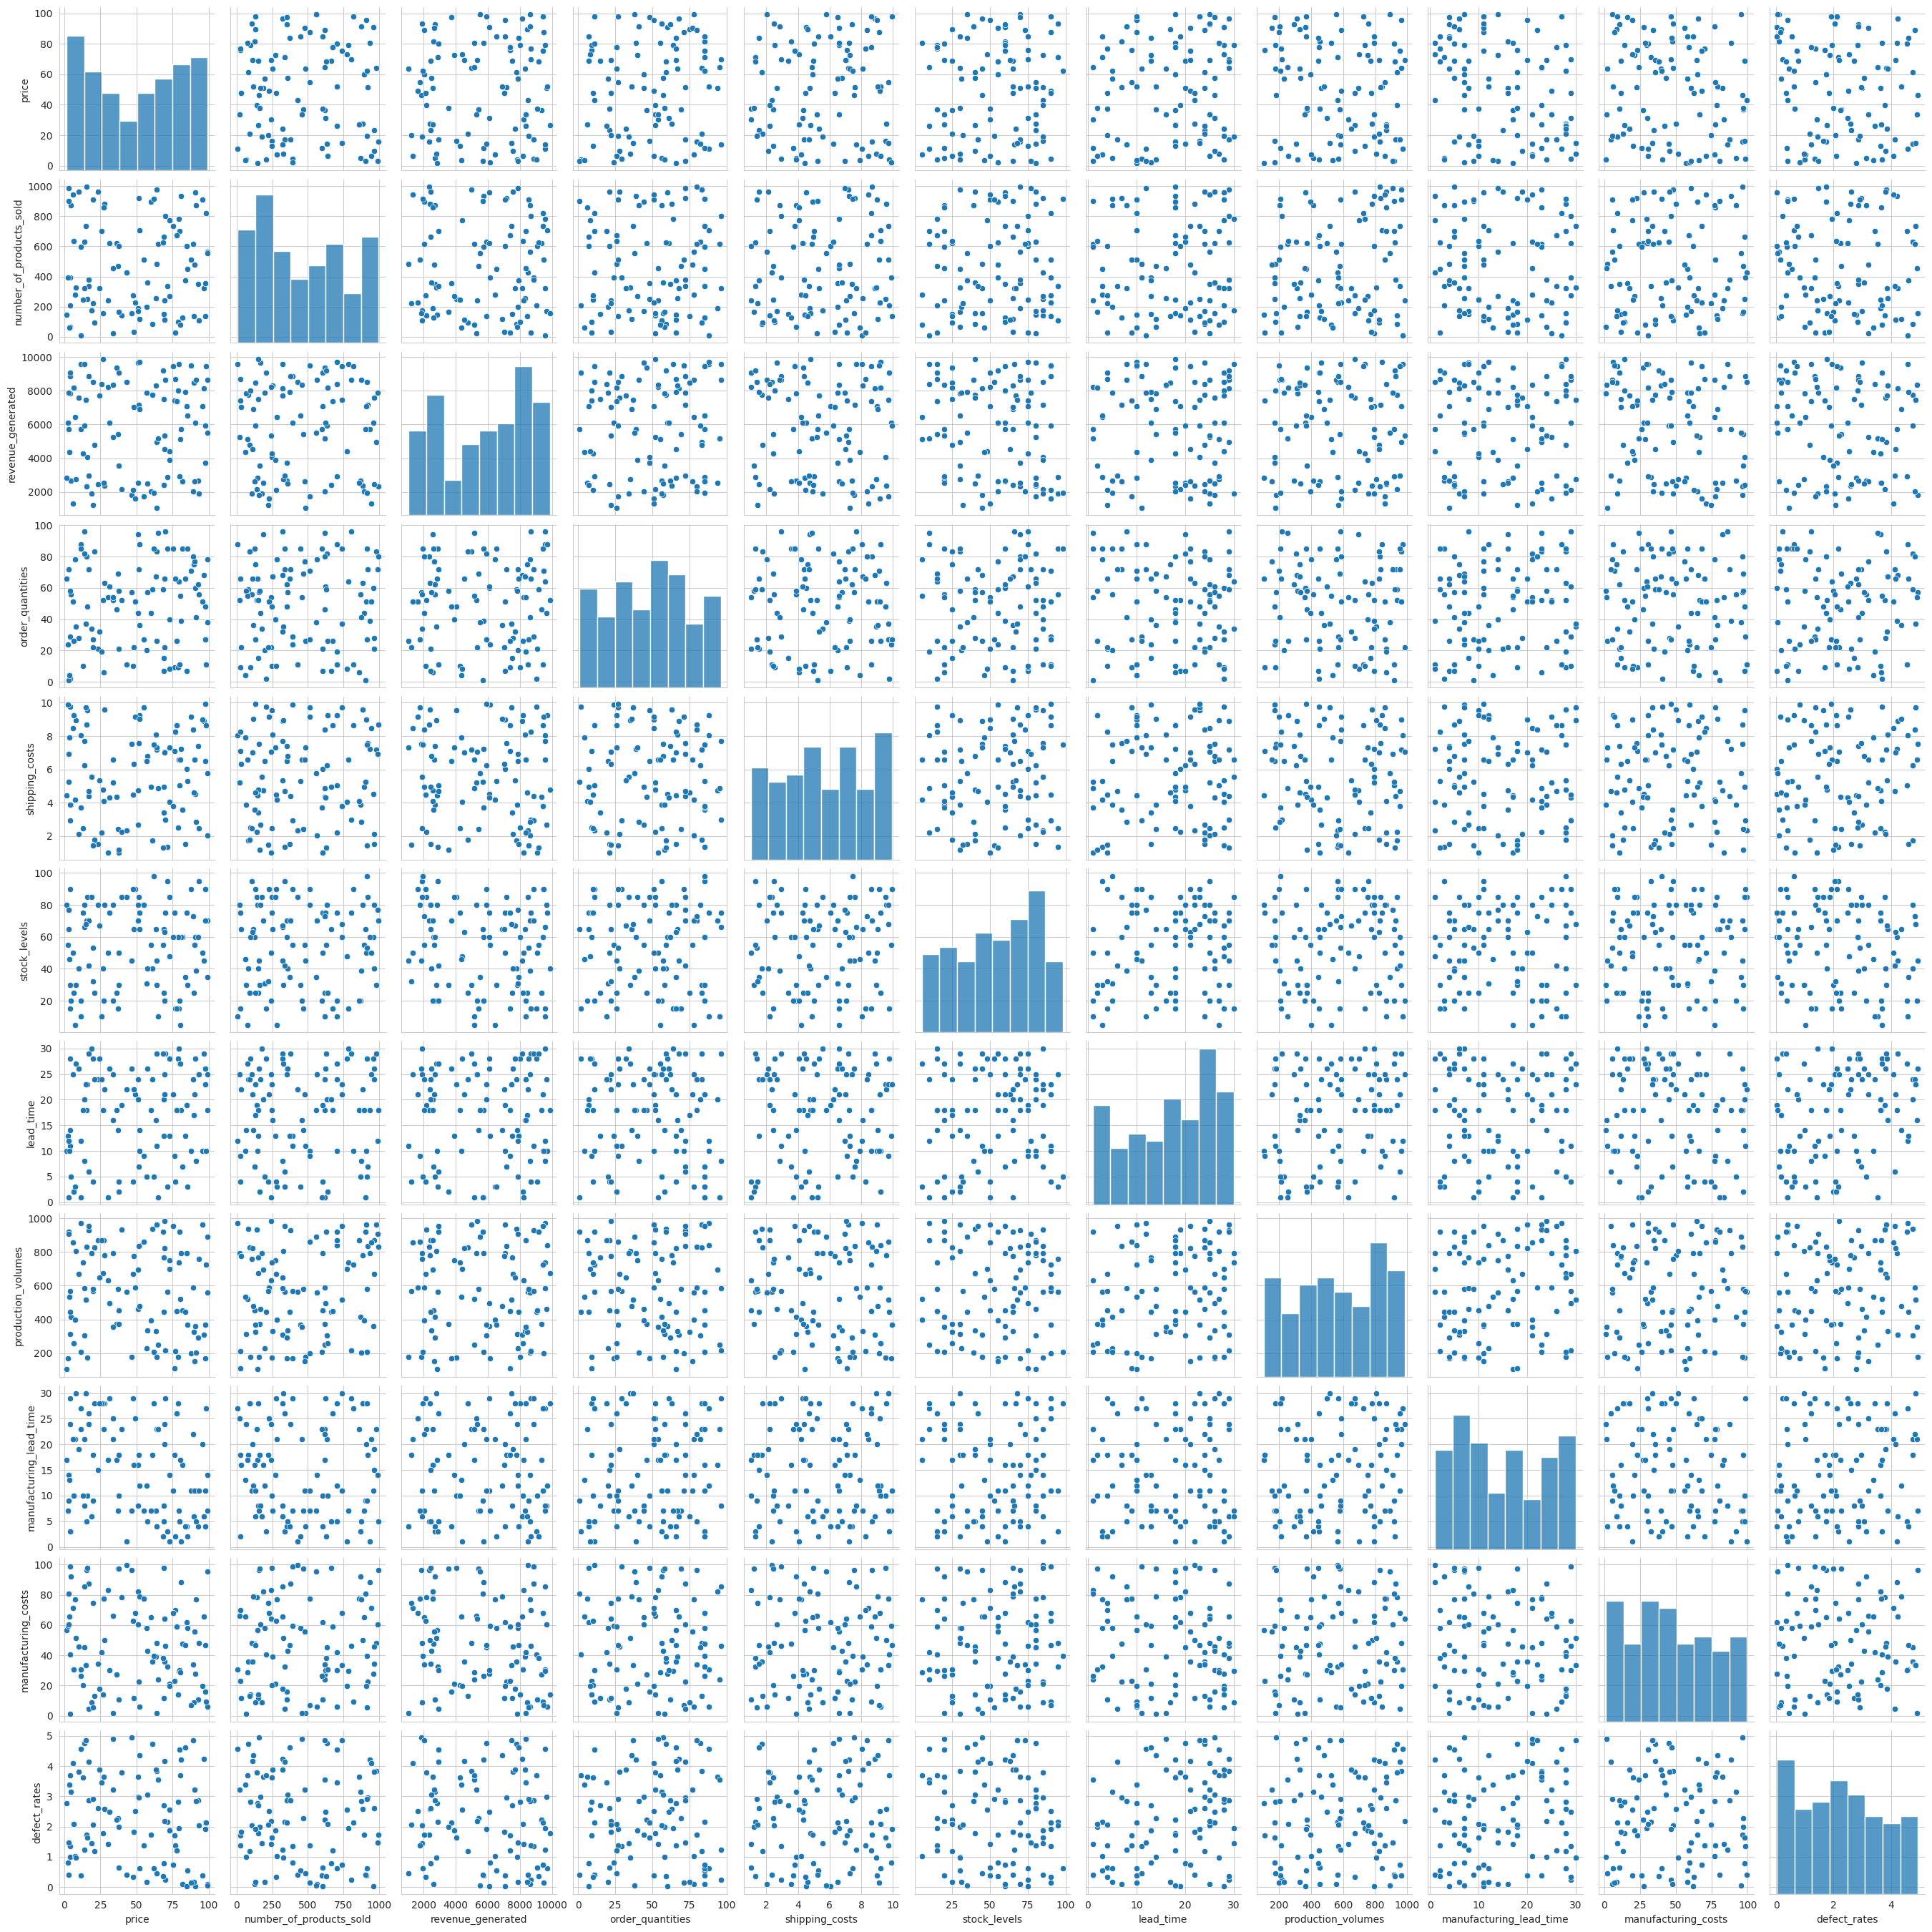

In [ ]:
STOCK=MP_SC[['price',
       'number_of_products_sold', 'revenue_generated', 'order_quantities',
        'shipping_costs', 'stock_levels',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'defect_rates']]
sb.pairplot(STOCK)

Observation:

Maximum SKU's price was between 0 to 20  price product got sold maximun

Maximum SKU's unit count is between 200 to 400 unit

Maximum SKU geneared revnue between 8000 to 9000 currency unit

Maximum SKU's order quantity is between 50 to 70

Maximum SKU's shiping cost is between 9-10

Maximum SKU's stock level is between 75-85

Maximum SKU's lead time is between 23-26

Maximum SKU procution volume is between 800-900

Maximum SKU's manufacturing lead time is between 4 to 8

Maximum SKU manufacturing cost is between 0-12 & 25 to 38

Maximum SKU defect rate is between 0 to 1.5




In [ ]:
corr=STOCK.corr()
corr

,price,number_of_products_sold,revenue_generated,order_quantities,shipping_costs,stock_levels,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates
price,1.000000,-0.013804,0.034420,0.097908,0.048224,0.098913,0.173343,-0.103702,-0.293663,-0.153206,-0.173973
number_of_products_sold,-0.013804,1.000000,0.017524,0.034708,0.043354,0.009374,0.025634,0.177091,-0.027462,0.051828,-0.071329
revenue_generated,0.034420,0.017524,1.000000,0.026592,-0.049567,-0.182834,-0.015300,-0.027458,0.020590,-0.208664,-0.130140
order_quantities,0.097908,0.034708,0.026592,1.000000,-0.046394,0.001996,-0.076738,-0.050946,0.090295,-0.000762,0.008706
shipping_costs,0.048224,0.043354,-0.049567,-0.046394,1.000000,0.090886,0.025429,-0.133459,0.022474,-0.012303,0.096375
stock_levels,0.098913,0.009374,-0.182834,0.001996,0.090886,1.000000,0.113886,0.056558,0.015218,0.034122,-0.119322
lead_time,0.173343,0.025634,-0.015300,-0.076738,0.025429,0.113886,1.000000,0.226497,0.042709,-0.114599,0.288944
production_volumes,-0.103702,0.177091,-0.027458,-0.050946,-0.133459,0.056558,0.226497,1.000000,0.171165,0.056221,0.099104
manufacturing_lead_time,-0.293663,-0.027462,0.020590,0.090295,0.022474,0.015218,0.042709,0.171165,1.000000,-0.156322,0.158641
manufacturing_costs,-0.153206,0.051828,-0.208664,-0.000762,-0.012303,0.034122,-0.114599,0.056221,-0.156322,1.000000,-0.021508


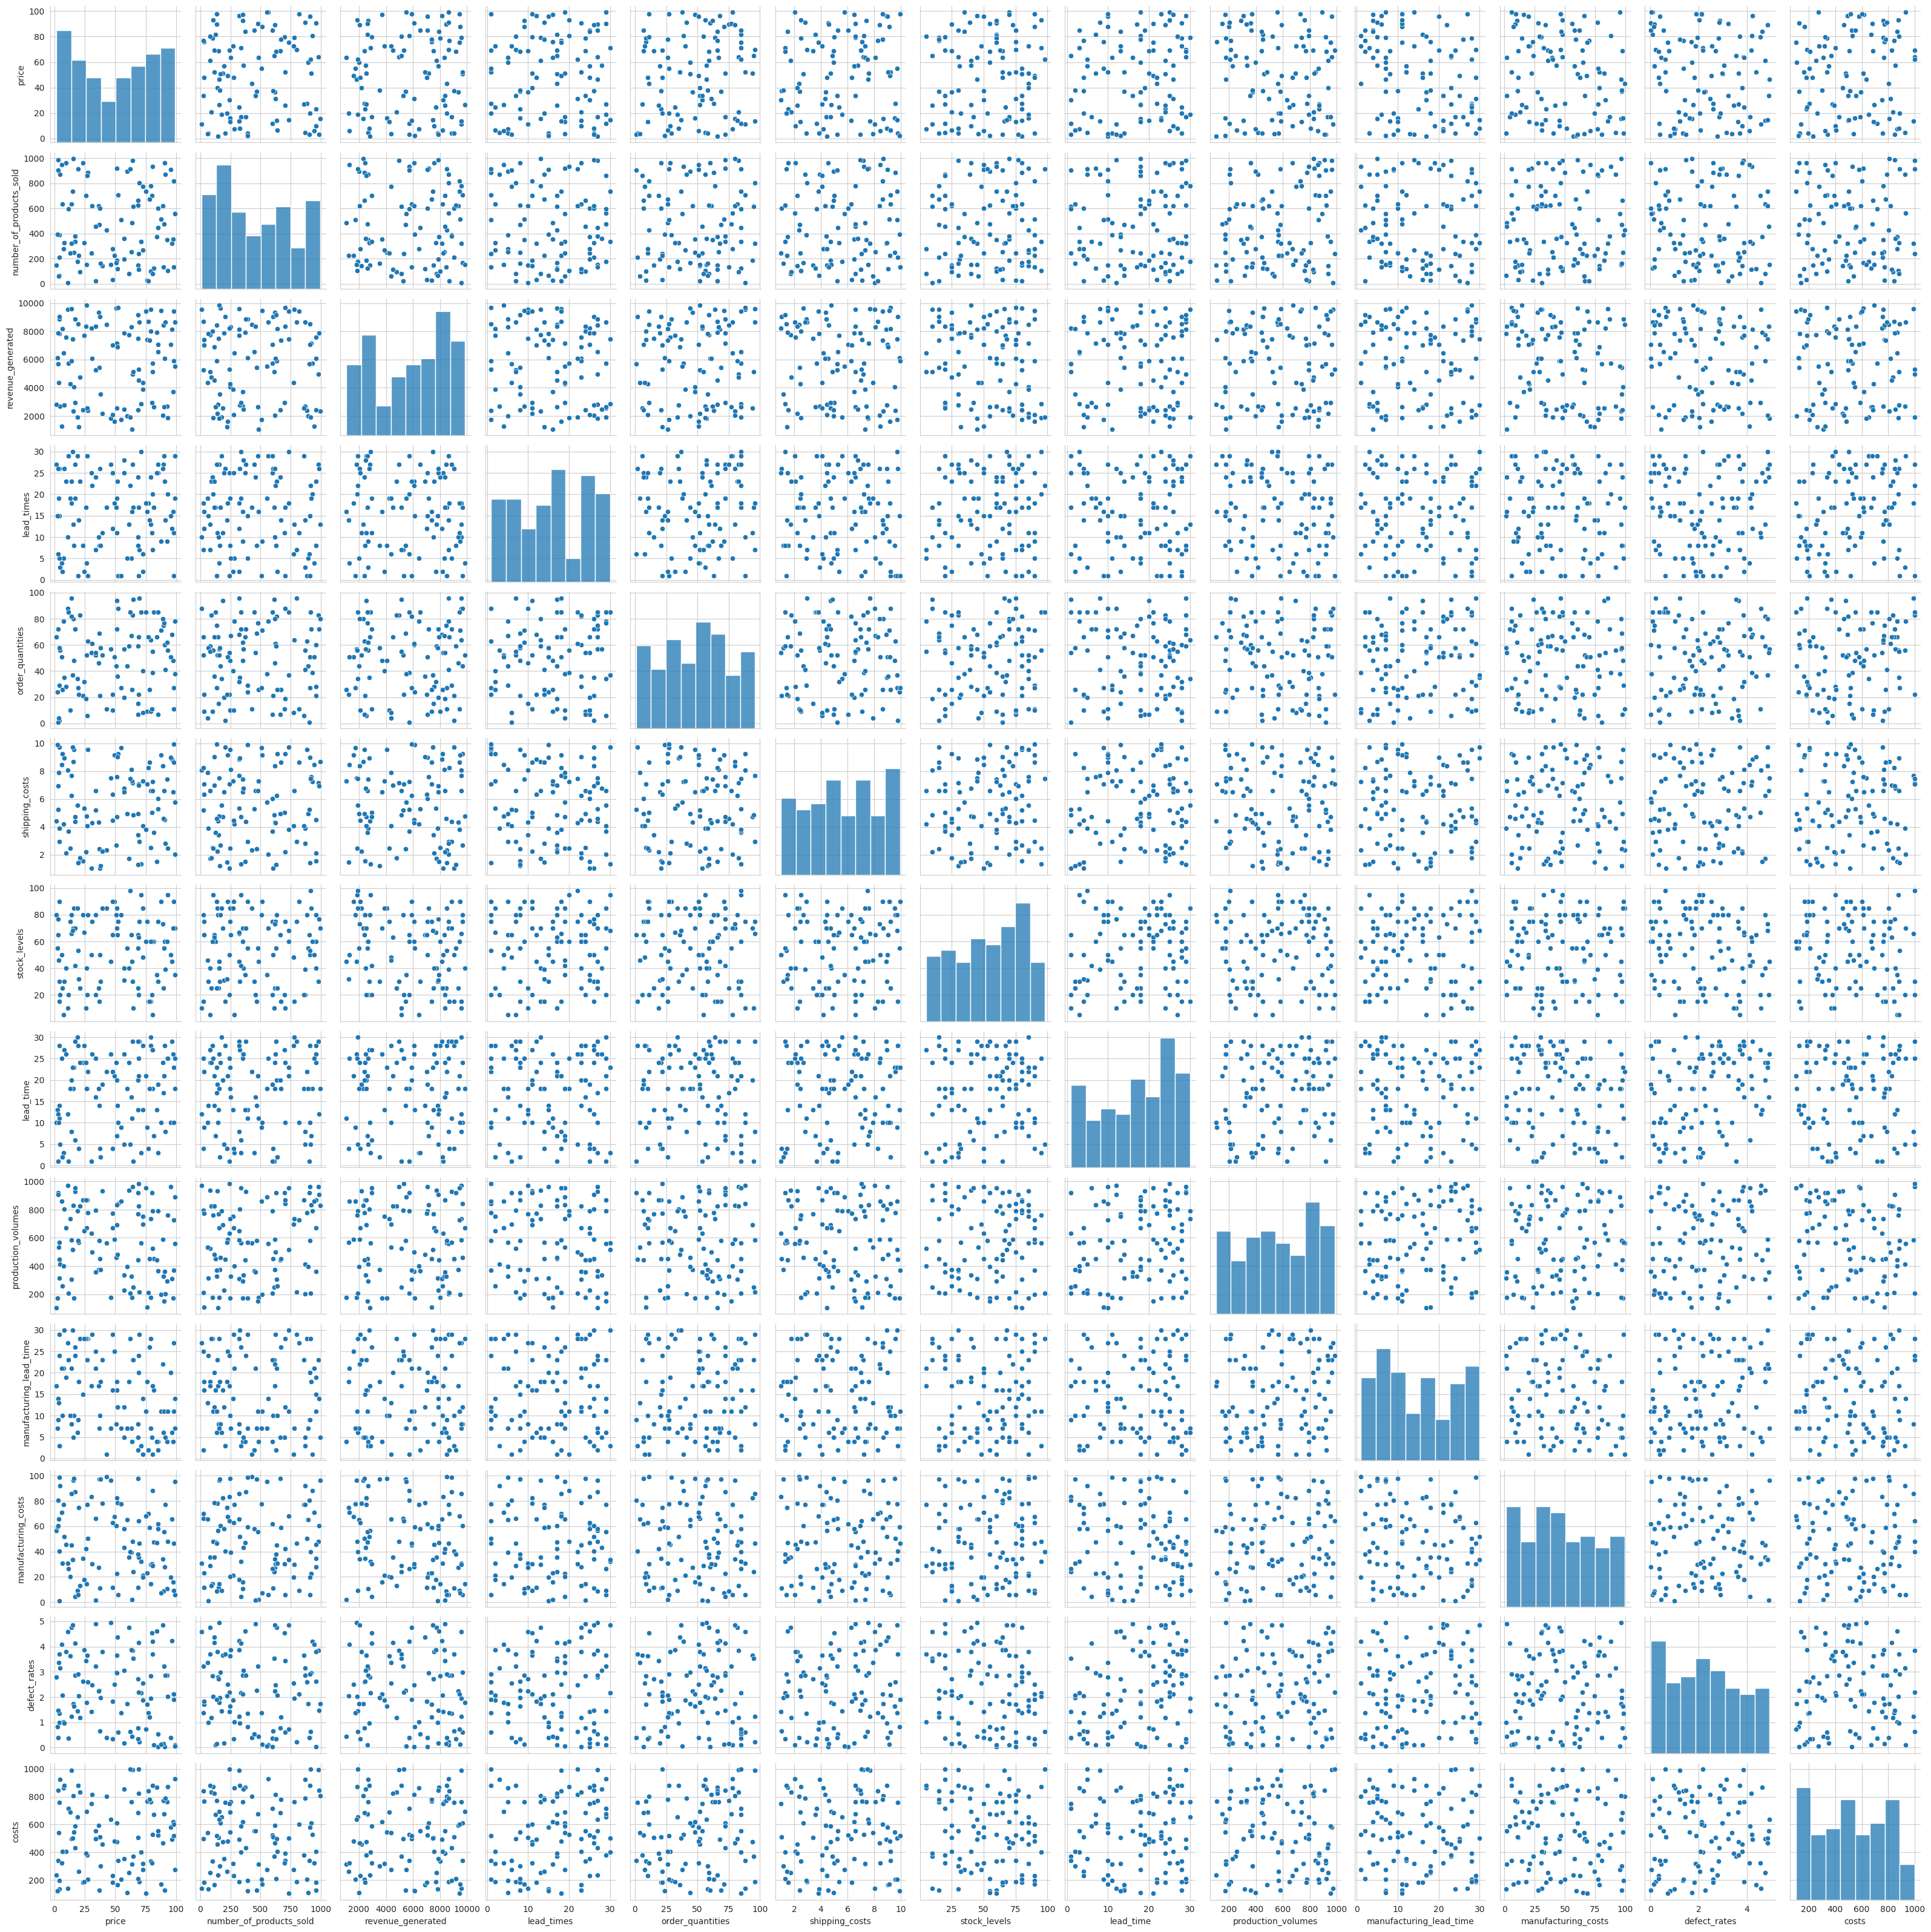

In [ ]:
COSTS=MP_SC[['price',
       'number_of_products_sold', 'revenue_generated', 'lead_times', 'order_quantities',
        'shipping_costs', 'stock_levels',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'defect_rates', 'costs']]
sb.pairplot(COSTS)

Obversation:

Maximum SKU's required lead time between 16 to 18

Maximum SKU's cost is between 0 to 200

In [ ]:
corr=COSTS.corr()
corr

,price,number_of_products_sold,revenue_generated,lead_times,order_quantities,shipping_costs,stock_levels,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates,costs
price,1.000000,-0.013804,0.034420,0.021092,0.097908,0.048224,0.098913,0.173343,-0.103702,-0.293663,-0.153206,-0.173973,0.086117
number_of_products_sold,-0.013804,1.000000,0.017524,-0.014464,0.034708,0.043354,0.009374,0.025634,0.177091,-0.027462,0.051828,-0.071329,-0.027699
revenue_generated,0.034420,0.017524,1.000000,-0.058434,0.026592,-0.049567,-0.182834,-0.015300,-0.027458,0.020590,-0.208664,-0.130140,0.000584
lead_times,0.021092,-0.014464,-0.058434,1.000000,0.126876,-0.138579,0.000755,0.020934,-0.108587,0.040005,-0.015427,0.047883,0.233722
order_quantities,0.097908,0.034708,0.026592,0.126876,1.000000,-0.046394,0.001996,-0.076738,-0.050946,0.090295,-0.000762,0.008706,0.146769
shipping_costs,0.048224,0.043354,-0.049567,-0.138579,-0.046394,1.000000,0.090886,0.025429,-0.133459,0.022474,-0.012303,0.096375,0.058118
stock_levels,0.098913,0.009374,-0.182834,0.000755,0.001996,0.090886,1.000000,0.113886,0.056558,0.015218,0.034122,-0.119322,-0.143627
lead_time,0.173343,0.025634,-0.015300,0.020934,-0.076738,0.025429,0.113886,1.000000,0.226497,0.042709,-0.114599,0.288944,0.036952
production_volumes,-0.103702,0.177091,-0.027458,-0.108587,-0.050946,-0.133459,0.056558,0.226497,1.000000,0.171165,0.056221,0.099104,-0.102651
manufacturing_lead_time,-0.293663,-0.027462,0.020590,0.040005,0.090295,0.022474,0.015218,0.042709,0.171165,1.000000,-0.156322,0.158641,-0.052305


# **Products Analysis**

In [ ]:
Product = MPSCData.groupby('product_type')
Route = MPSCData.groupby('routes')
Customer=MPSCData.groupby('customer_demographics')
Shipping=MPSCData.groupby('shipping_carriers')
Location=MPSCData.groupby('location')
Transportation=MPSCData.groupby('transportation_modes')

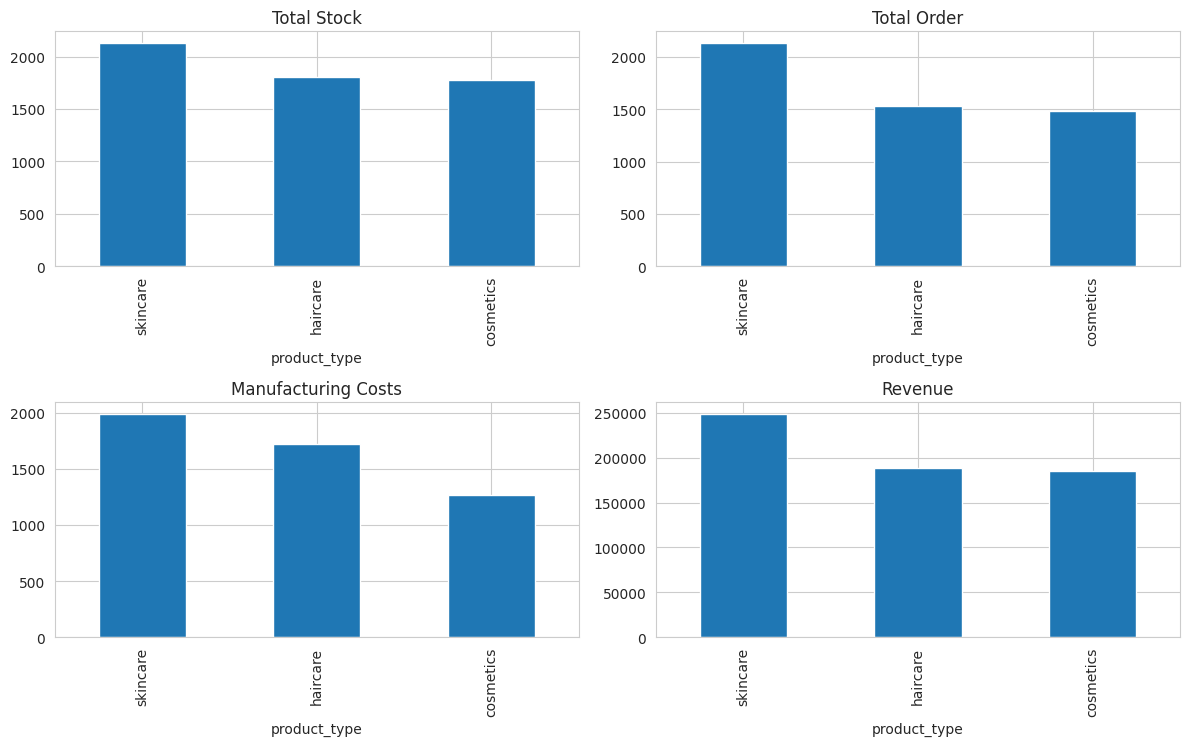

In [ ]:
import plotly.express as px
plt.figure(figsize=(8,8))
plt.subplot(4, 2, 1)
Product['stock_levels'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Total Stock")

plt.subplot(4, 2, 2)
Product['order_quantities'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Total Order")

plt.subplot(4, 2, 3)
Product['manufacturing_costs'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Manufacturing Costs")

plt.subplot(4, 2, 4)
Product['revenue_generated'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Revenue")

plt.tight_layout()
plt.show()

data_Products=MPSCData.groupby(['product_type'])['sku'].count().reset_index(name='number_of_products_sold').sort_values(by= 'number_of_products_sold', ascending= False)
px.pie(data_Products, values='number_of_products_sold', names= 'product_type' , title= 'Total Number of Products Sold',
       color='product_type',
             color_discrete_map={'cosmetics':'skyblue',
                                 'haircare':'navajowhite',
                              'skincare':'lawngreen'})

# **Customers Analysis**

In [ ]:
data_Customers=MPSCData.groupby(['customer_demographics'])['sku'].count().reset_index(name='number_of_products_sold').sort_values(by= 'number_of_products_sold', ascending= False)
px.pie(data_Customers, values='number_of_products_sold', names= 'customer_demographics' , title= 'Customer Segment',
       color='customer_demographics',
             color_discrete_map={'Female':'lightgreen',
                                 'Male':'blue',
                                 'Non-binary':'orange',
                              'Unknown':'crimson'})

# **Customer Segment by Products**

In [ ]:
Customer_Segment_by_Products= MPSCData.groupby(["customer_demographics","product_type"])["sku"].count().reset_index()
Customer_Segment_by_Products

,customer_demographics,product_type,sku
0,Female,cosmetics,11
1,Female,haircare,3
2,Female,skincare,14
3,Male,cosmetics,5
4,Male,haircare,10
5,Male,skincare,7
6,Non-binary,cosmetics,5
7,Non-binary,haircare,7
8,Non-binary,skincare,11
9,Unknown,cosmetics,8


In [ ]:
bar_Customer_Segment_by_Products = px.bar(Customer_Segment_by_Products, x='customer_demographics', y='sku', \
    title='Customer Segment by Products',color='product_type')
bar_Customer_Segment_by_Products.show()

# **Routes Analysis**

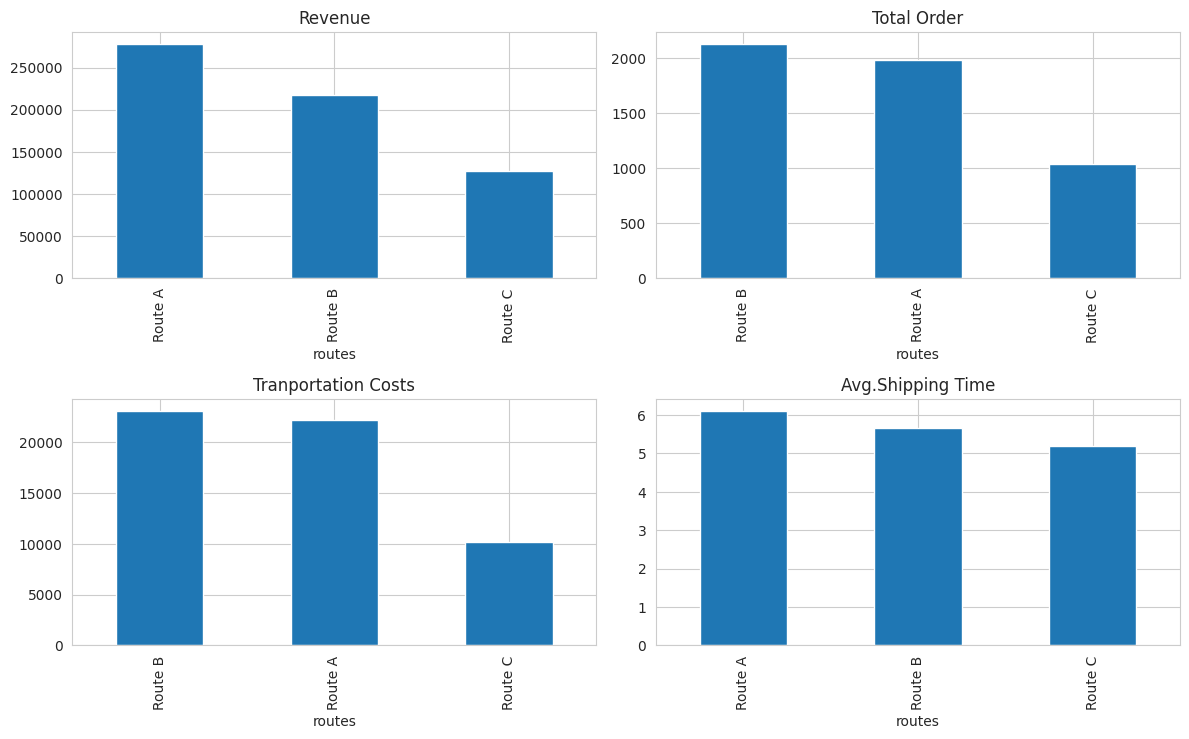

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(4, 2, 1)
Route['revenue_generated'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Revenue")

plt.subplot(4, 2, 2)
Route['order_quantities'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Total Order")

plt.subplot(4, 2, 3)
Route['costs'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Tranportation Costs")

plt.subplot(4, 2, 4)

Route['shipping_times'].mean().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Avg.Shipping Time")

plt.tight_layout()
plt.show()


data_Routes=MPSCData.groupby(['routes'])['sku'].count().reset_index(name='number_of_products_sold').sort_values(by= 'number_of_products_sold', ascending= False)
px.pie(data_Routes, values='number_of_products_sold', names= 'routes' , title= 'Routes',
       color='routes',color_discrete_map={'Route A':'purple','Route B':'lime','Route C':'bisque'})

# **Transportation Modes**

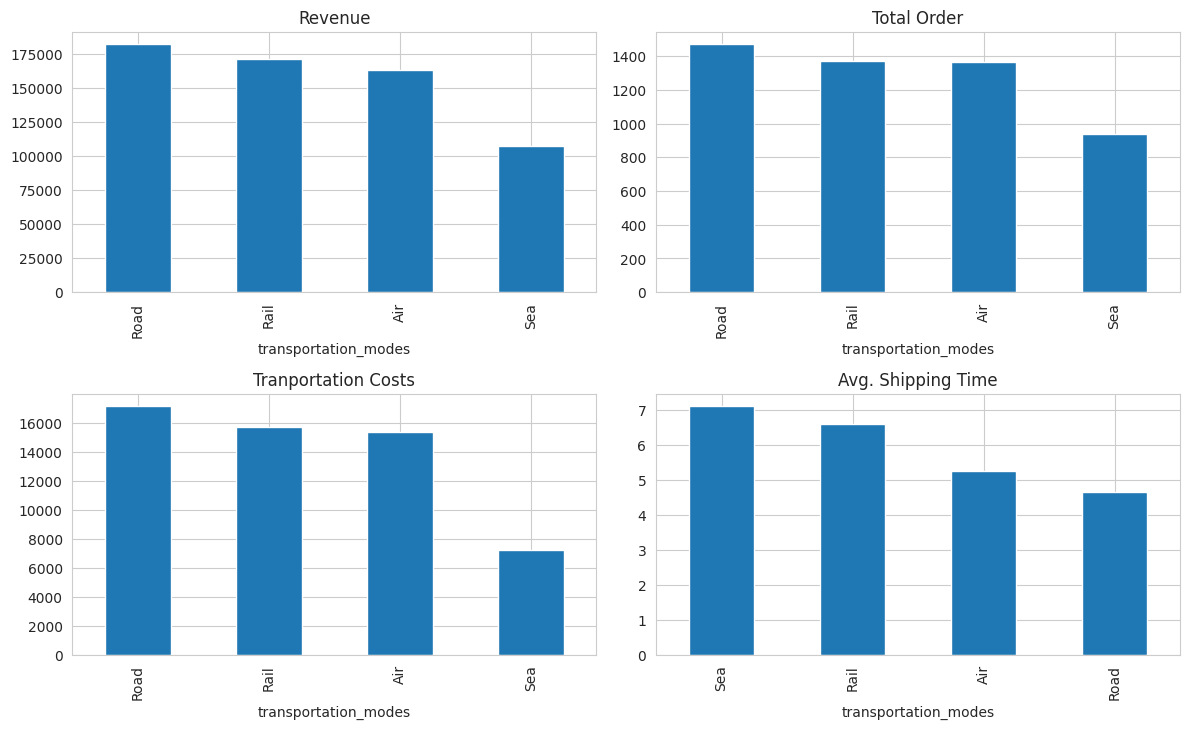

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(4, 2, 1)
Transportation['revenue_generated'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Revenue")

plt.subplot(4, 2, 2)
Transportation['order_quantities'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Total Order")

plt.subplot(4, 2, 3)
Transportation['costs'].sum().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Tranportation Costs")

plt.subplot(4, 2, 4)

Transportation['shipping_times'].mean().sort_values(ascending=False).plot.bar(figsize=(12,14), title="Avg. Shipping Time")

plt.tight_layout()
plt.show()

data_Transportation=MPSCData.groupby(['transportation_modes'])['sku'].count().reset_index(name='number_of_products_sold').sort_values(by= 'number_of_products_sold',
                                                                                                                                      ascending= False)
px.pie(data_Transportation, values='number_of_products_sold', names= 'transportation_modes' , title= 'Transportation Modes',
       color='transportation_modes',color_discrete_map={'Air':'deepskyblue','Rail':'burlywood','Road':'yellowgreen','Sea':'aquamarine'})

# **Routes and Transportation modes**

In [ ]:
Routes_by_Transportation= MPSCData.groupby(["routes","transportation_modes"])["sku"].count().reset_index()
Routes_by_Transportation

,routes,transportation_modes,sku
0,Route A,Air,12
1,Route A,Rail,14
2,Route A,Road,12
3,Route A,Sea,8
4,Route B,Air,7
5,Route B,Rail,12
6,Route B,Road,14
7,Route B,Sea,6
8,Route C,Air,8
9,Route C,Rail,3


In [ ]:
bar_Routes_by_Transportation = px.bar(Routes_by_Transportation, x='routes', y='sku', title='Routes_by_Transportation Modes',color='transportation_modes')
bar_Routes_by_Transportation.show()

# **Regression Models- Supervised learning**

In [ ]:
from sklearn.model_selection import train_test_split
train_MPSC = MP_SC.copy()

In [ ]:
X=train_MPSC[[ 'sku', 'price',
        'revenue_generated', 'shipping_costs',
        'production_volumes',
       'manufacturing_costs','routes','defect_rates' ]]
Y=train_MPSC['stock_levels']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()# Scale the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train a linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

LinearRegression()

In [ ]:
# Evaluate the model on the testing set
from sklearn.metrics import mean_absolute_error   #,mean_squared_error,accuracy_score,roc_auc_score
Y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 25.186560427644952


**On average, the model predicts the stock level with an error of about 25.18 units.**